In [1]:
!python --version

Python 3.11.14


In [2]:
import os, sys
import pandas as pd

from pathlib import Path

ROOT = Path().resolve().parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.calc_degs_lib import CALC_DEGS
from libs.tcga_gdc_lib import *
from libs.Basic import *


ROOT: /home/flavio/uv/perturb_agent
SRC added: /home/flavio/uv/perturb_agent/src


### Defaults

In [3]:
ROOT = Path().resolve().parent
root0 = ROOT / "data"

gdc = GDC(root0=root0)

os.listdir(root0)[:10]


['cancer', 'reactome', 'vector_store', 'TCGA', 'gdc_programs.txt']

### Get all programs

In [4]:
force=False
verbose=True

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)


File read at '/home/flavio/uv/perturb_agent/data/gdc_programs.txt'


In [5]:
np.array(prog_list)

array(['TCGA', 'MATCH', 'TARGET', 'CGCI', 'CMI', 'APOLLO', 'BEATAML1.0',
       'CPTAC', 'MP2PRT', 'ALCHEMIST', 'CCDI', 'CCG', 'CDDP_EAGLE',
       'CTSP', 'EXCEPTIONAL_RESPONDERS', 'FM', 'HCMI', 'MMRF', 'NCICCR',
       'OHSU', 'ORGANOID', 'RC', 'REBC', 'TRIO', 'VAREPOP', 'WCDT'],
      dtype='<U22')

### Primary sites given a program

In [6]:
gdc.url_gdc_project

'https://api.gdc.cancer.gov/projects'

In [7]:
force=False
verbose=False

prog_id = 'TCGA'

gdc.set_program(prog_id)
df_psi = gdc.get_primary_sites(prog_id=prog_id, force=False, verbose=verbose)

i=0
primary_site = df_psi.iloc[i].primary_site
gdc.set_primary_site(primary_site=primary_site) 


True

In [8]:
df_cases, df_all_samples, df_all_mut, barcode_list = gdc.get_filtered_tables(primary_site=primary_site, verbose=verbose)
len(df_all_mut), len(barcode_list)

No mutation analysis file found for: TCGA-ACC_Adrenal_gland_subtype_sarcoma_tumor_sarcoma_subtype_tissue_sarcoma


(10778, 51)

In [9]:
barcode_samples = np.unique(df_all_samples.barcode_sample)
len(barcode_samples)

84

In [10]:
sample_types = np.unique(df_all_samples.sample_type)
sample_types

array(['Primary Tumor'], dtype=object)

In [11]:
cols = ['barcode', 'sample', 
       'symbol', 'refseq_mrna_id', 'entrez_gene_id', 'protein_mut',
       'mutation_type', 'ref_allele', 'variant_allele',
       'variant_type', 'chr', 'start', 'end', 'mutation_status',]

df_all_mut[cols].head()

,barcode,sample,symbol,refseq_mrna_id,entrez_gene_id,protein_mut,mutation_type,ref_allele,variant_allele,variant_type,chr,start,end,mutation_status
0,TCGA-OR-A5J2,1,CTNNB1,NM_001904.3,1499,Y30*,Nonsense_Mutation,-,A,INS,3,41266091,41266092,.
1,TCGA-OR-A5J2,1,FLNA,NM_001110556.1,2316,K2563N,Missense_Mutation,C,A,SNP,23,153577797,153577797,.
2,TCGA-OR-A5J2,1,GFRA1,NM_005264.4,2674,R224Q,Missense_Mutation,C,T,SNP,10,117884831,117884831,.
3,TCGA-OR-A5J2,1,HIVEP2,NM_006734.3,3097,I220V,Missense_Mutation,T,C,SNP,6,143095218,143095218,.
4,TCGA-OR-A5J2,1,IGSF3,NM_001542.3,3321,E339K,Missense_Mutation,C,T,SNP,1,117150771,117150771,.


### Mutations

In [12]:
df_all_mut.columns

Index(['pid', 'molecular_profile_id', 'barcode', 'sample', 'barcode_sample',
       'symbol', 'refseq_mrna_id', 'entrez_gene_id', 'protein_mut',
       'mutation_type', 'mutation_status', 'ref_allele', 'variant_allele',
       'variant_type', 'chr', 'start', 'end', 'validation_status',
       'protein_pos_start', 'protein_pos_end', 'tumor_alt_count', 'ncbi_build',
       'center', 'tumor_ref_count', 'unique_sample_key', 'unique_patient_key'],
      dtype='object')

In [13]:
df_all_mut.barcode.iloc[:4]

0    TCGA-OR-A5J2
1    TCGA-OR-A5J2
2    TCGA-OR-A5J2
3    TCGA-OR-A5J2
Name: barcode, dtype: object

In [14]:
barcode_list[:4]

['TCGA-OR-A5J2-01', 'TCGA-OR-A5J4-01', 'TCGA-OR-A5J5-01', 'TCGA-OR-A5J7-01']

In [15]:
df4 = df_all_mut[df_all_mut.barcode_sample.isin(barcode_list)]
len(df4), len(df_all_mut)

(10778, 10778)

### Mutations --> pivot: barcodes x genes

In [16]:
dfpiv = gdc.build_pivot_table(df_all_mut)

dfpiv.head(3)

symbol,A1BG,A2ML1,A4GALT,AACS,ABCA12,ABCA13,ABCA2,ABCA3,ABCA5,ABCA6,...,ZRANB3,ZRSR2P1,ZSCAN18,ZSCAN20,ZSWIM3,ZSWIM6,ZSWIM8,ZW10,ZZEF1,ZZZ3
barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5J4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5J5,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,True,True,False,False,False


### UMAP cluster

#### Jaccard distance

Jaccard distance is a measure of dissimilarity between two sets, derived directly from Jaccard similarity. While Jaccard similarity measures how much two sets overlap, Jaccard distance measures how different they are. It is defined as one minus the Jaccard similarity.


$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$

In [17]:
k = 4

embedding, labels = gdc.calc_UMAP(dfpiv, k)

df_umap = pd.DataFrame(
    embedding,
    index=dfpiv.index,
    columns=["UMAP1", "UMAP2"]
)

print(labels)
df_umap.head(6)

[3, 0, 0, 0, 1, 0, 0, 1, 2, 3, 1, 1, 1, 2, 3, 1, 0, 3, 1, 1, 0, 3, 1, 0, 0, 1, 3, 2, 0, 2, 1, 2, 3, 2, 3, 2, 2, 0, 3, 1, 1, 0, 0, 0, 3, 0, 2, 1, 3, 2]


,UMAP1,UMAP2
barcode,,
TCGA-OR-A5J2,8.708974,11.693614
TCGA-OR-A5J4,10.661012,10.152798
TCGA-OR-A5J5,10.199286,9.185333
TCGA-OR-A5J7,9.362281,9.748220
TCGA-OR-A5J8,8.680501,9.612644
TCGA-OR-A5JA,10.246691,10.065502


### UMAP plot

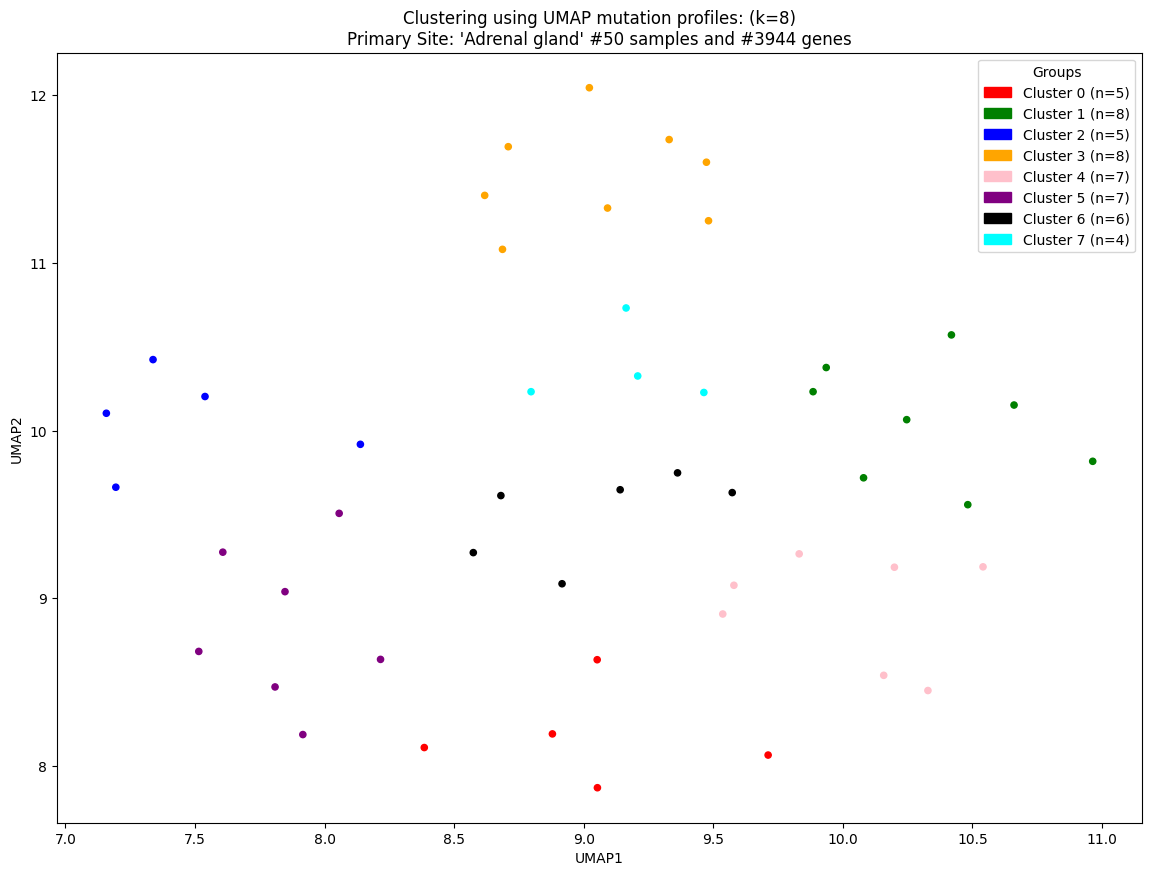

In [18]:
fig, embedding, labels = gdc.plot_umap(dfpiv, k=8)

In [19]:
selK = 1

barcodes = np.array(dfpiv.index.to_list())
selected_list = [True if x == selK else False for x in labels]

sel_barcodes = barcodes[selected_list]

print(sum(selected_list), len(sel_barcodes))
print("\n".join(sel_barcodes))

8 8
TCGA-OR-A5J4
TCGA-OR-A5JA
TCGA-OR-A5JX
TCGA-OR-A5KW
TCGA-OR-A5LL
TCGA-OR-A5LT
TCGA-P6-A5OF
TCGA-P6-A5OH


### My k-cluster 

In [20]:
dfpiva = dfpiv[dfpiv.index.isin(sel_barcodes)]
print(dfpiva.shape)

dfpiva

(8, 3944)


symbol,A1BG,A2ML1,A4GALT,AACS,ABCA12,ABCA13,ABCA2,ABCA3,ABCA5,ABCA6,...,ZRANB3,ZRSR2P1,ZSCAN18,ZSCAN20,ZSWIM3,ZSWIM6,ZSWIM8,ZW10,ZZEF1,ZZZ3
barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5JA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5JX,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5KW,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-OR-A5LL,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
TCGA-OR-A5LT,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
TCGA-P6-A5OF,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-P6-A5OH,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [21]:
dfpiva_filt = dfpiva.loc[:, dfpiva.sum(axis=0) >= 2]
dfpiva_filt.shape


(8, 22)

In [22]:
def cluster_mutation_table2(dfpiv: pd.DataFrame, cluster:int=1, min_barcodes:int=2) -> pd.DataFrame:
    

    barcodes = np.array(dfpiv.index.to_list())
    selected_list = [True if x == cluster else False for x in labels]

    sel_barcodes = barcodes[selected_list]

    dfpiva = dfpiv[dfpiv.index.isin(sel_barcodes)]

    dfpiva_filt = dfpiva.loc[:, dfpiva.sum(axis=0) >= min_barcodes]

    return dfpiva_filt


dfpiva_filt = cluster_mutation_table2(dfpiv, cluster=2, min_barcodes=2)
dfpiva_filt.shape



(5, 4)

In [23]:
type(labels), labels[:4]

(list, [3, 1, 4, 6])

In [24]:
def cluster_mutation_table(dfpiv:pd.DataFrame, labels, cluster:int=1,
                           min_barcodes:int=2) -> pd.DataFrame:

    labels = pd.Series(labels, index=dfpiv.index)
    sel_barcodes = labels[labels == cluster].index
    dff = dfpiv.loc[sel_barcodes]
    dff = dff.loc[:, dff.sum(axis=0) >= min_barcodes]

    return dff

cluster=0
dff = cluster_mutation_table(dfpiv, labels, cluster=cluster, min_barcodes=2)
dff.shape

(5, 5)

In [25]:
dfpiva_filt

symbol,CNTNAP5,CTLA4,DNAH3,SLC5A5
barcode,,,,
TCGA-OR-A5JL,True,False,False,False
TCGA-OR-A5JO,False,True,False,False
TCGA-OR-A5JW,False,False,True,True
TCGA-OR-A5JZ,True,False,False,True
TCGA-OR-A5K2,True,True,True,False


In [26]:
gene_degree = dff.sum(axis=0).sort_values(ascending=False)
barcode_degree = dff.sum(axis=1).sort_values(ascending=False)

gsize = dff.shape[0]
ngenes = dff.shape[1]
print("cluster size:", gsize)
print("genes kept:", ngenes)

print("\nTop genes:")
print(gene_degree.head(20))

print("\nTop barcodes by mutation burden:")
print(barcode_degree.head(20))

cluster size: 5
genes kept: 5

Top genes:
symbol
TOPAZ1      3
ARHGEF28    2
DAAM1       2
PRKAG2      2
SVEP1       2
dtype: int64

Top barcodes by mutation burden:
barcode
TCGA-OR-A5KZ    3
TCGA-PK-A5HC    3
TCGA-OR-A5KV    2
TCGA-OR-A5L4    2
TCGA-OR-A5LK    1
dtype: int64


### Normalizing

In [27]:
def cluster_gene_frequency_table(dfpiv: pd.DataFrame, Kmin:int=2, Kmax:int=10, min_barcodes: int = 1) -> pd.DataFrame:

    df_list = []
    for k in range(Kmin, Kmax + 1):
        embedding, labels = gdc.calc_UMAP(dfpiv, k)

        min_cluster = np.min(labels)
        max_cluster = np.max(labels)

        
        for cluster in range(min_cluster, max_cluster + 1):
            dfc = cluster_mutation_table(
                dfpiv=dfpiv,
                labels=labels,
                cluster=cluster,
                min_barcodes=min_barcodes
            )

            n_cluster = dfc.shape[0]
            gene_degree = dfc.sum(axis=0).sort_values(ascending=False)
            gene_freq = (gene_degree / n_cluster).sort_values(ascending=False)

            df_all_mut = pd.DataFrame({
                "k": k,
                "cluster": cluster,
                "gene": gene_degree.index,
                "degree": gene_degree.values,
                "cluster_size": n_cluster,
                "freq": gene_freq.values
            })
            df_list.append(df_all_mut)

    df = pd.concat(df_list, ignore_index=True)

    return df

In [28]:
dfstat = cluster_gene_frequency_table(dfpiv, Kmin=2, Kmax=10, min_barcodes=1)
len(dfstat)

40806

In [29]:
dfstat.head(30)

,k,cluster,gene,degree,cluster_size,freq
0,2,0,CTNNB1,8,30,0.266667
1,2,0,TP53,7,30,0.233333
2,2,0,HMCN1,5,30,0.166667
3,2,0,TTN,5,30,0.166667
4,2,0,MEN1,5,30,0.166667
5,2,0,DST,5,30,0.166667
6,2,0,PCDH15,4,30,0.133333
7,2,0,ATM,4,30,0.133333
8,2,0,LRP1,4,30,0.133333
9,2,0,RYR2,4,30,0.133333


In [39]:

def calc_shannon_entropy_from_dfstat(dfstat: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (k, cluster), dfsub in dfstat.groupby(["k", "cluster"]):
        deg_list = dfsub["degree"].to_list()

        if len(deg_list) == 0:
            H = np.nan
            Hmax = np.nan
            Hnorm = np.nan
            n_genes = 0
        else:
            w = np.array(deg_list, dtype=float)
            p = w / w.sum()
            H = -np.sum(p * np.log2(p))
            n_genes = len(p)
            Hmax = np.log2(n_genes) if n_genes > 1 else 0.0
            Hnorm = H / Hmax if Hmax > 0 else 0.0

        rows.append({
            "k": k,
            "cluster": cluster,
            "n_genes": n_genes,
            "cluster_size": dfsub["cluster_size"].iloc[0],
            "entropy": H,
            "entropy_max": Hmax,
            "entropy_norm": Hnorm
        })

    return pd.DataFrame(rows)

In [40]:
dfh = calc_shannon_entropy_from_dfstat(dfstat)

dfh

,k,cluster,n_genes,cluster_size,entropy,entropy_max,entropy_norm
0,2,0,3544,30,11.700130,11.791163,0.992280
1,2,1,602,20,9.176446,9.233620,0.993808
2,3,0,1090,11,10.062641,10.090112,0.997277
3,3,1,565,19,9.084884,9.142107,0.993741
4,3,2,2747,20,11.358321,11.423641,0.994282
5,4,0,2684,15,11.329798,11.390169,0.994700
6,4,1,439,14,8.726281,8.778077,0.994099
7,4,2,226,10,7.792731,7.820179,0.996490
8,4,3,1090,11,10.062641,10.090112,0.997277
9,5,0,248,8,7.926037,7.954196,0.996460


In [32]:
dfh = dfh.sort_values('entropy_norm', ascending=False)
dfh.head(12)

,k,cluster,n_genes,cluster_size,entropy,entropy_max,entropy_norm
35,9,0,674,6,9.385979,9.396605,0.998869
46,10,2,674,6,9.385979,9.396605,0.998869
34,8,7,1102,4,10.093452,10.105909,0.998767
51,10,7,177,4,7.455647,7.467606,0.998399
44,10,0,57,4,5.823498,5.832890,0.998390
41,9,6,1197,6,10.207936,10.225207,0.998311
28,8,1,803,8,9.631284,9.649256,0.998137
26,7,6,803,8,9.631284,9.649256,0.998137
18,6,4,803,8,9.631284,9.649256,0.998137
24,7,4,1814,7,10.804253,10.824959,0.998087


### weighted mean entropy

In [41]:
def score_k_from_entropy_table(dfh: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for k, sub in dfh.groupby("k"):
        total_n = sub["cluster_size"].sum()

        weighted_mean_entropy = (
            (sub["entropy_norm"] * sub["cluster_size"]).sum() / total_n
            if total_n > 0 else np.nan
        )

        mean_entropy = sub["entropy_norm"].mean()
        std_entropy = sub["entropy_norm"].std()
        min_cluster_size = sub["cluster_size"].min()
        max_cluster_size = sub["cluster_size"].max()
        n_clusters = sub.shape[0]
        n_small_clusters = (sub["cluster_size"] < 3).sum()

        rows.append({
            "k": k,
            "n_clusters": n_clusters,
            "weighted_mean_hnorm": weighted_mean_entropy,
            "mean_hnorm": mean_entropy,
            "std_hnorm": std_entropy,
            "min_cluster_size": min_cluster_size,
            "max_cluster_size": max_cluster_size,
            "n_small_clusters_lt3": n_small_clusters
        })

    return pd.DataFrame(rows).sort_values("weighted_mean_hnorm", ascending=True)

In [42]:
dfw = score_k_from_entropy_table(dfh)
dfw

,k,n_clusters,weighted_mean_hnorm,mean_hnorm,std_hnorm,min_cluster_size,max_cluster_size,n_small_clusters_lt3
0,2,2,0.992891,0.993044,0.001081,20,30,0
1,3,3,0.994735,0.995100,0.001905,11,20,0
4,6,6,0.995448,0.995536,0.003234,7,11,0
2,4,4,0.995457,0.995642,0.001490,10,15,0
5,7,7,0.995495,0.995703,0.003119,4,9,0
6,8,8,0.995669,0.995950,0.003074,4,8,0
7,9,9,0.995816,0.996059,0.003060,3,8,0
8,10,10,0.996240,0.996711,0.002804,3,8,0
3,5,5,0.996334,0.996436,0.001419,8,13,0
